In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import warnings 



In [3]:
df = pd.read_csv('accepted.csv', low_memory=False)

df = df[df["loan_status"].isin(["Fully Paid", "Charged Off"])].copy()


TARGET = "charged_off"
df[TARGET] = (df["loan_status"] == "Charged Off").astype(int)
df.drop(columns=["loan_status"], inplace=True)



In [4]:
keep_cols = [
    "loan_amnt",
    "term",
    "int_rate",
    "installment",
    "grade",
    "sub_grade",
    "purpose",
    "initial_list_status",
    "application_type",  

    "emp_length",
    "home_ownership",
    "annual_inc",
    "verification_status",
    "addr_state",
    "dti",
    "dti_joint", 

    "earliest_cr_line",  
    "issue_d",
    "fico_range_low",
    "inq_last_6mths",
    "inq_last_12m",
    "mths_since_last_delinq",
    "mths_since_last_record",
    "mths_since_recent_inq",
    "delinq_2yrs",
    "open_acc",
    "pub_rec",
    "pub_rec_bankruptcies",
    "tax_liens",
    "total_acc",
    "mort_acc",

    "revol_bal",
    "revol_util",
    "bc_util",
    "total_rev_hi_lim",
    "tot_cur_bal",
    "tot_coll_amt",
    "avg_cur_bal",
    "acc_now_delinq",

    "num_accts_ever_120_pd",
    "num_tl_90g_dpd_24m",
    "pct_tl_nvr_dlq",
    "chargeoff_within_12_mths",
]

In [5]:
keep_cols = [c for c in keep_cols if c in df.columns]
df = df[keep_cols + [TARGET]].copy()
print(f"After column selection: {df.shape[1] - 1} features + target")

print(f"\nTarget distribution:\n{df[TARGET].value_counts()}")
print(f"Charged-off rate: {df[TARGET].mean():.1%}")

After column selection: 43 features + target

Target distribution:
charged_off
0    1076751
1     268559
Name: count, dtype: int64
Charged-off rate: 20.0%


# Converting Dates 

In [ ]:
def parse_lc_date(series):
    return pd.to_datetime(series, format="%b-%Y", errors="coerce")
 
if "issue_d" in df.columns:
    df["loan_vintage_yr"] = parse_lc_date(df["issue_d"]).dt.year
    df.drop(columns=["issue_d"], inplace=True)
 
if "earliest_cr_line" in df.columns:
    reference_date = pd.Timestamp("2018-01-01")
    df["credit_history_yrs"] = (
        (reference_date - parse_lc_date(df["earliest_cr_line"])).dt.days / 365.25
    ).round(1)
    df.drop(columns=["earliest_cr_line"], inplace=True)

if "term" in df.columns:
    df["term"] = df["term"].str.extract(r"(\d+)").astype(float)

for col in ["int_rate", "revol_util"]:
    if col in df.columns and df[col].dtype == object:
        df[col] = df[col].str.replace("%", "").astype(float)

if "emp_length" in df.columns:
    emp_map = {
        "< 1 year": 0, "1 year": 1, "2 years": 2, "3 years": 3,
        "4 years": 4, "5 years": 5, "6 years": 6, "7 years": 7,
        "8 years": 8, "9 years": 9, "10+ years": 10
    }
    df["emp_length"] = df["emp_length"].map(emp_map)
 

# Cleaning Nulls

In [7]:
null_pct = df.isnull().mean().sort_values(ascending=False)
print("\n── Null % per column (top 20) ──")
print(null_pct[null_pct > 0].head(20).map("{:.1%}".format))


── Null % per column (top 20) ──
dti_joint                   98.1%
mths_since_last_record      83.0%
inq_last_12m                60.0%
mths_since_last_delinq      50.5%
mths_since_recent_inq       12.9%
emp_length                   5.8%
pct_tl_nvr_dlq               5.0%
avg_cur_bal                  5.0%
total_rev_hi_lim             5.0%
num_tl_90g_dpd_24m           5.0%
tot_cur_bal                  5.0%
tot_coll_amt                 5.0%
num_accts_ever_120_pd        5.0%
bc_util                      4.6%
mort_acc                     3.5%
revol_util                   0.1%
pub_rec_bankruptcies         0.1%
dti                          0.0%
chargeoff_within_12_mths     0.0%
tax_liens                    0.0%
dtype: str


## dropping null rows since not many (could replaACE w median but eh)
## Filling mths_since_last_delin1 with 999 since null here means never been delinquent not actuall null
## I am dropping dti_joint, mths_since_last_record , inq_last_12m, since highest null percentages. 

In [8]:
df["mths_since_last_delinq"] = df["mths_since_last_delinq"].fillna(999)

null_thresh = 0.50
null_pct = df.isnull().mean()
drop_cols = null_pct[null_pct > null_thresh].index.tolist()
df.drop(columns=drop_cols, inplace=True)

num_cols = df.select_dtypes(include="number").columns.drop(TARGET, errors="ignore").tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

df[num_cols] = df[num_cols].fillna(df[num_cols].median())
df[cat_cols] = df[cat_cols].fillna(df[cat_cols].mode().iloc[0])

In [9]:
# splits between data type
num_cols = df.select_dtypes(include="number").columns.drop(TARGET, errors="ignore").tolist()
cat_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print(f"\nFinal shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"  Numeric features  : {len(num_cols)}")
print(f"  Categorical features: {len(cat_cols)}")


Final shape: 1,345,310 rows × 41 columns
  Numeric features  : 32
  Categorical features: 8


In [ ]:
plot_dir = "eda_plots"
import os; os.makedirs(plot_dir, exist_ok=True)

for col in num_cols:
    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    fig.suptitle(col, fontsize=13, fontweight="bold")

    sns.histplot(df[col].dropna(), kde=True, ax=axes[0], color="#4C72B0")
    axes[0].set_xlabel(col)

    sns.boxplot(data=df, x=TARGET, y=col, ax=axes[1],
    palette={"0": "#55A868", "1": "#C44E52"})

    plt.tight_layout()
    plt.savefig(f"{plot_dir}/{col}_dist.png")
    plt.close()

for col in cat_cols:
    top_vals = df[col].value_counts().nlargest(10).index
    plot_df = df[df[col].isin(top_vals)]

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    fig.suptitle(col, fontsize=13, fontweight="bold")

    order = plot_df[col].value_counts().index
    sns.countplot(data=plot_df, y=col, order=order, ax=axes[0], color="#4C72B0")

    rate = plot_df.groupby(col)[TARGET].mean().reindex(order)
    rate.plot(kind="barh", ax=axes[1], color="#C44E52")
    axes[1].set_xlabel("Charged-off rate")
    axes[1].axvline(df[TARGET].mean(), color="black", linestyle="--",
                    linewidth=1, label=f"Overall avg ({df[TARGET].mean():.1%})")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
  
    plt.close()

                variable  correlation  p_value
                int_rate       0.2588  0.00000
                    term       0.1761  0.00000
          fico_range_low      -0.1307  0.00000
                     dti       0.0845  0.00000
             avg_cur_bal      -0.0748  0.00000
                mort_acc      -0.0725  0.00000
             tot_cur_bal      -0.0671  0.00000
               loan_amnt       0.0656  0.00000
          inq_last_6mths       0.0655  0.00000
                 bc_util       0.0643  0.00000
              revol_util       0.0600  0.00000
             installment       0.0517  0.00000
         loan_vintage_yr       0.0514  0.00000
        total_rev_hi_lim      -0.0502  0.00000
   mths_since_recent_inq      -0.0477  0.00000
      credit_history_yrs      -0.0440  0.00000
              annual_inc      -0.0418  0.00000
                open_acc       0.0281  0.00000
                 pub_rec       0.0262  0.00000
    pub_rec_bankruptcies       0.0253  0.00000
             

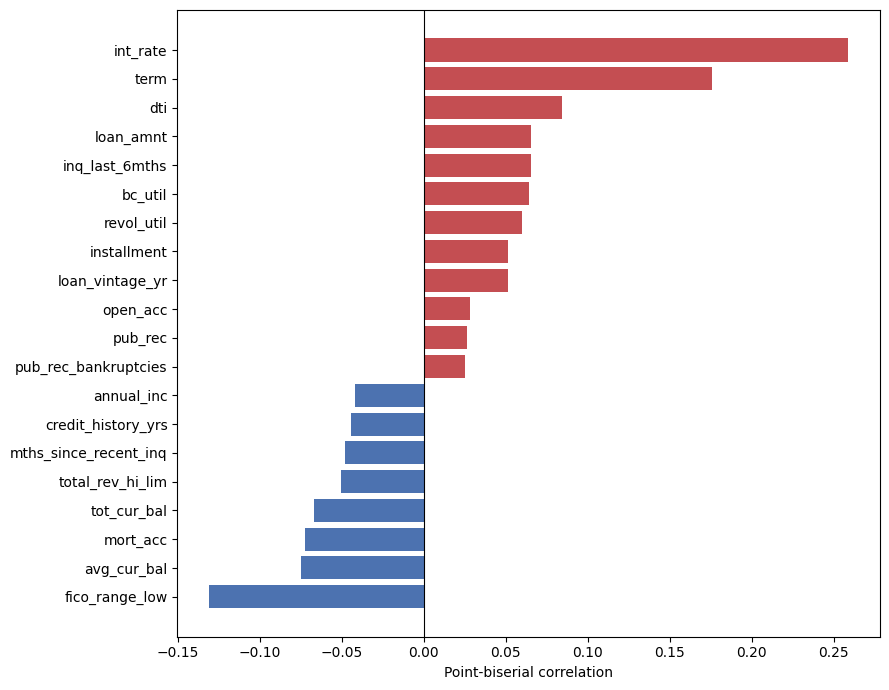

In [ ]:
corr_rows = []
for col in num_cols:
    r, p = stats.pointbiserialr(df[TARGET], df[col])
    corr_rows.append({"variable": col, "correlation": round(r, 4), "p_value": round(p, 5)})

corr_df = (pd.DataFrame(corr_rows)
             .sort_values("correlation", key=abs, ascending=False))
print(corr_df.to_string(index=False))

top20 = corr_df.head(20).sort_values("correlation")
fig, ax = plt.subplots(figsize=(9, 7))
colors = ["#C44E52" if v > 0 else "#4C72B0" for v in top20["correlation"]]
ax.barh(top20["variable"], top20["correlation"], color=colors)
ax.axvline(0, color="black", linewidth=0.8)
ax.set_xlabel("Point-biserial correlation")
plt.tight_layout()

plt.show()
plt.close()

           variable  cramers_v
          sub_grade     0.2679
              grade     0.2619
verification_status     0.0920
     home_ownership     0.0708
            purpose     0.0555
         addr_state     0.0503
   application_type     0.0162
initial_list_status     0.0073


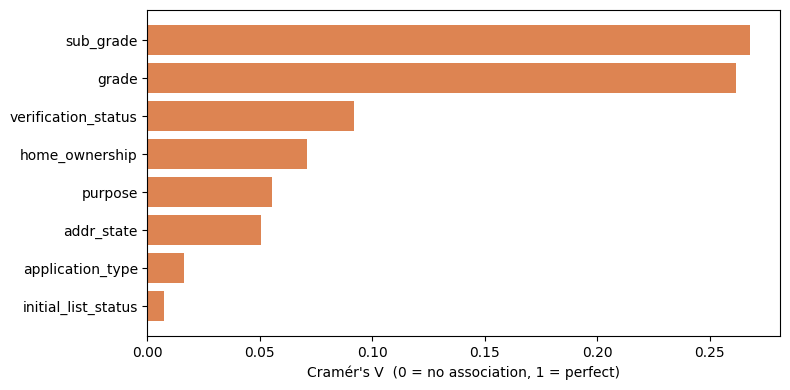

In [ ]:
def cramers_v(col):
    ct = pd.crosstab(df[col], df[TARGET])
    chi2 = stats.chi2_contingency(ct, correction=False)[0]
    n = ct.values.sum()
    r, c = ct.shape
    return round(np.sqrt(chi2 / (n * (min(r, c) - 1))), 4)

cat_assoc = pd.DataFrame({
    "variable": cat_cols,
    "cramers_v": [cramers_v(c) for c in cat_cols]
}).sort_values("cramers_v", ascending=False)
print(cat_assoc.to_string(index=False))

fig, ax = plt.subplots(figsize=(8, max(4, len(cat_cols) * 0.35)))
cat_assoc_sorted = cat_assoc.sort_values("cramers_v")
ax.barh(cat_assoc_sorted["variable"], cat_assoc_sorted["cramers_v"], color="#DD8452")
ax.set_xlabel("Cramér's V  (0 = no association, 1 = perfect)")
plt.tight_layout()

plt.show()
plt.close()

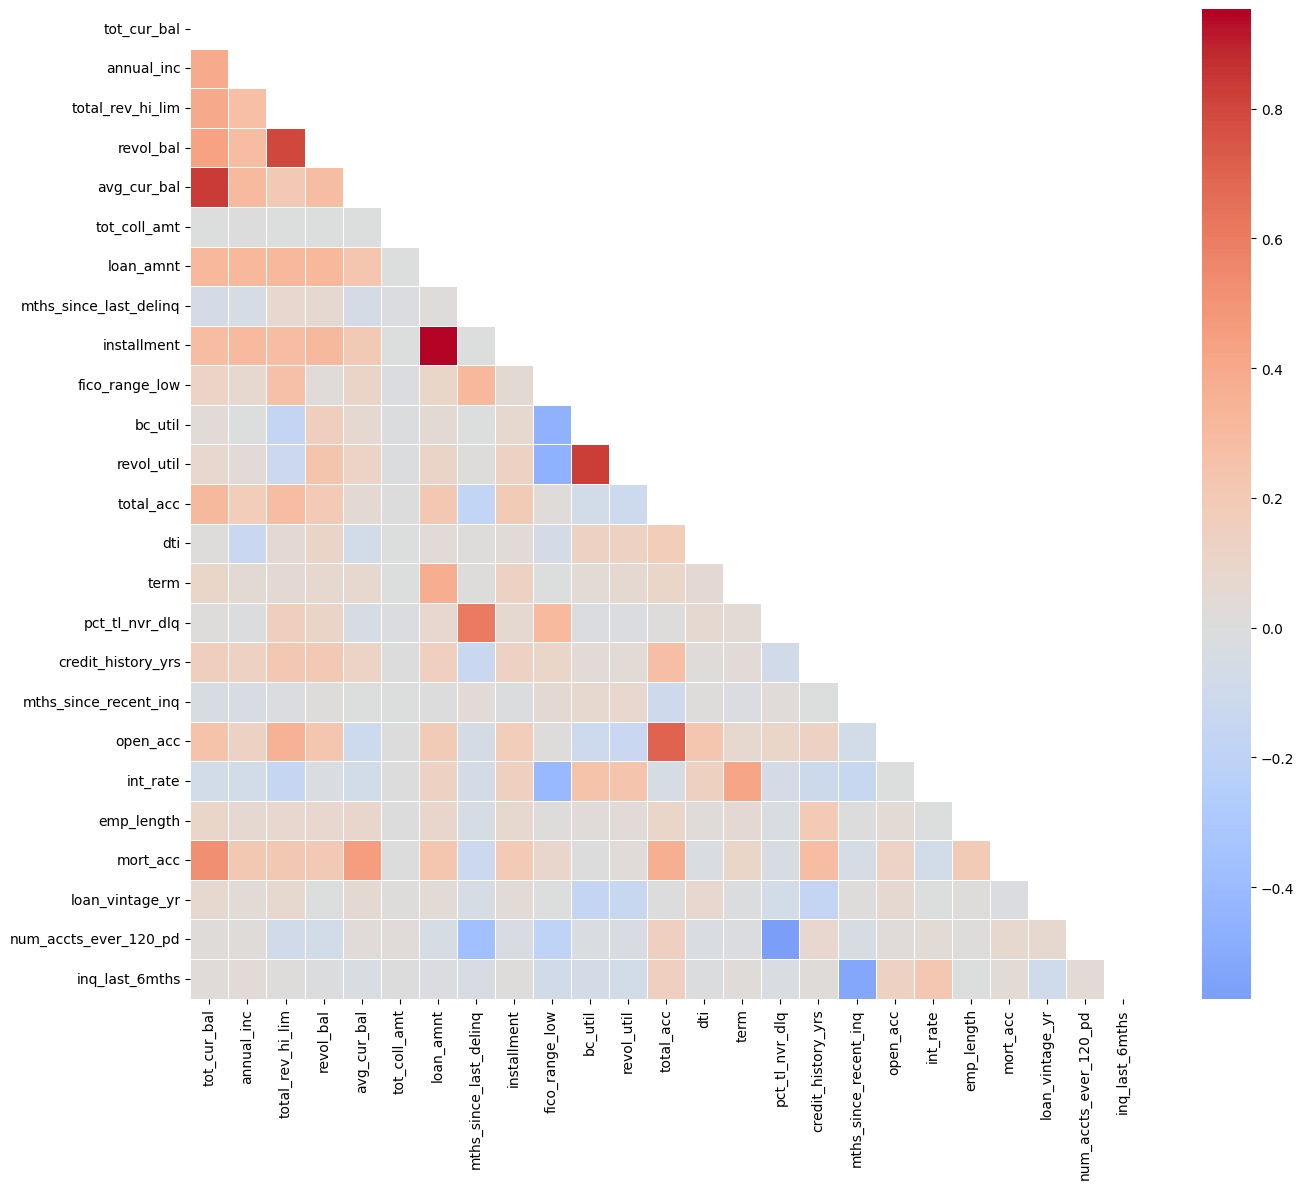

In [13]:
top25 = df[num_cols].var().nlargest(25).index.tolist()
fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones((len(top25), len(top25)), dtype=bool))
sns.heatmap(df[top25].corr(), mask=mask, annot=False, cmap="coolwarm",
            center=0, linewidths=0.4, ax=ax)
plt.tight_layout()
plt.savefig(f"{plot_dir}/heatmap_numeric.png")
plt.show()
plt.close()

In [14]:
summary = df[num_cols + [TARGET]].describe().T
summary.to_csv(f"{plot_dir}/summary_stats.csv")
print(summary)

                              count           mean            std      min  \
loan_amnt                 1345310.0   14419.972014    8717.050787   500.00   
term                      1345310.0      41.790196      10.268321    36.00   
int_rate                  1345310.0      13.239619       4.768716     5.31   
installment               1345310.0     438.075533     261.512604     4.93   
emp_length                1345310.0       5.967865       3.581850     0.00   
annual_inc                1345310.0   76247.636414   69925.098427     0.00   
dti                       1345310.0      18.282480      11.158900    -1.00   
fico_range_low            1345310.0     696.185039      31.852512   625.00   
inq_last_6mths            1345310.0       0.655080       0.937774     0.00   
mths_since_last_delinq    1345310.0     521.021586     482.571100     0.00   
mths_since_recent_inq     1345310.0       6.491535       5.488582     0.00   
delinq_2yrs               1345310.0       0.317794       0.87799

<function matplotlib.pyplot.show(close=None, block=None)>

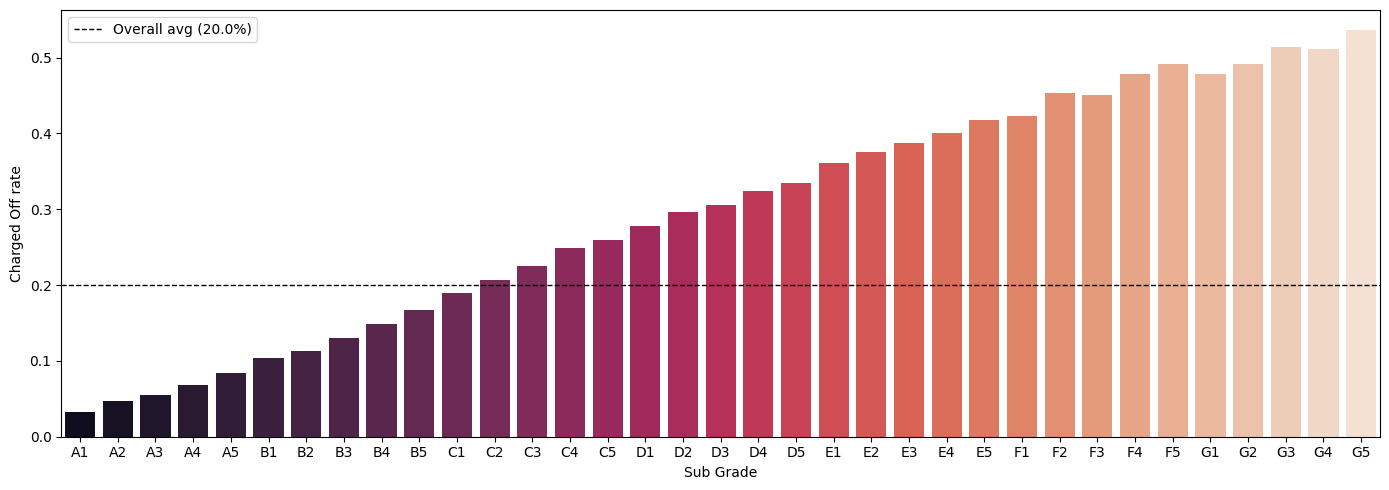

In [15]:
order = [f"{g}{n}" for g in "ABCDEFG" for n in range(1,6)]
rate = df.groupby("sub_grade")[TARGET].mean().reindex(order)

fig, ax = plt.subplots(figsize=(14,5))
sns.barplot(x=rate.index, y=rate.values, hue=rate.index, palette="rocket", ax=ax)
ax.axhline(df[TARGET].mean(), color="black", linestyle="--", linewidth=1,
           label=f"Overall avg ({df[TARGET].mean():.1%})")
ax.set_xlabel("Sub Grade")
ax.set_ylabel("Charged Off rate")
ax.legend()
plt.tight_layout()
plt.show

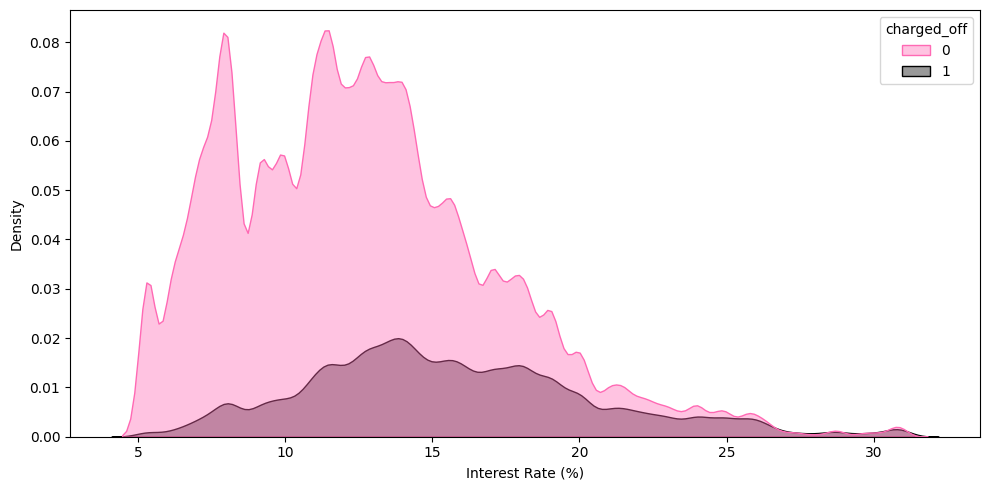

In [16]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.kdeplot(data=df, x="int_rate", hue=TARGET,
            palette={0: "hotpink", 1: "black"}, fill=True, alpha=0.4, ax=ax)
ax.set_xlabel("Interest Rate (%)")
plt.tight_layout()
plt.show()

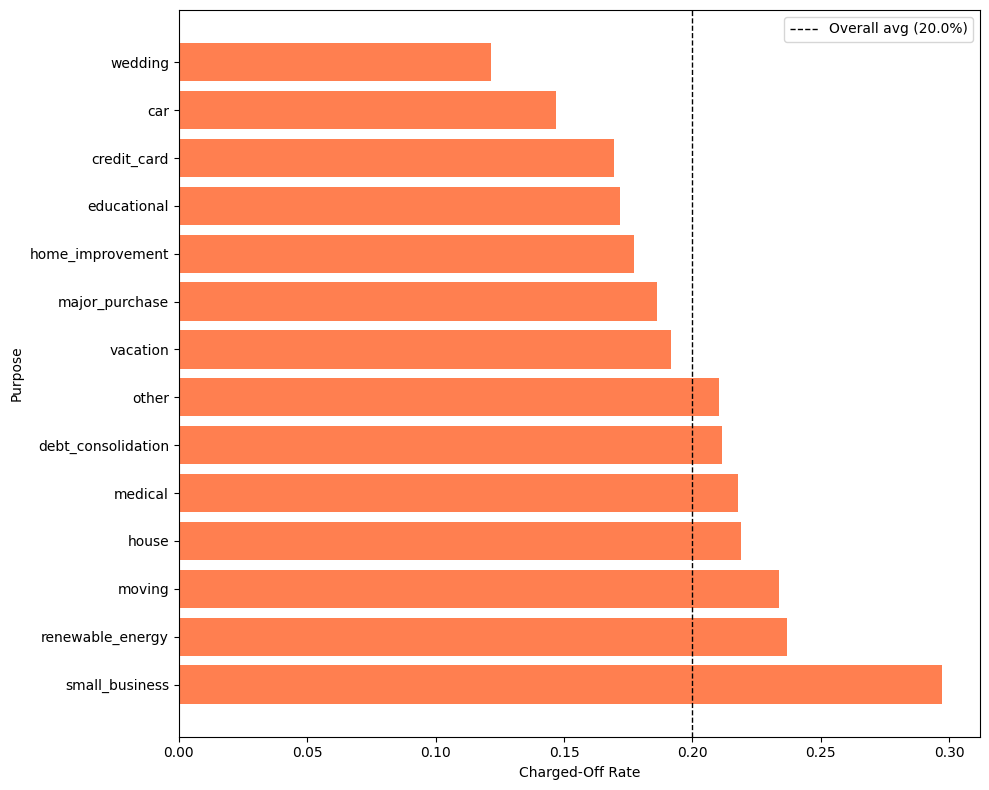

In [18]:
purpose_rate = df.groupby("purpose")[TARGET].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10,8))
bars = ax.barh(purpose_rate.index, purpose_rate.values, color="coral")
ax.axvline(df[TARGET].mean(), color="black", linestyle="--", linewidth=1,
           label=f"Overall avg ({df[TARGET].mean():.1%})")
ax.set_xlabel("Charged-Off Rate")
ax.set_ylabel("Purpose")
ax.legend()
plt.tight_layout()
plt.show()
plt.close()


In [19]:
print(df.shape[0])

1345310
